# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df = pd.read_csv("../data/stock_data.csv")

# Data Understanding

In [3]:
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [4]:
df.shape

(2518, 6)

In [5]:
df.columns

Index(['Date', ' Close/Last', ' Volume', ' Open', ' High', ' Low'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         2518 non-null   str  
 1    Close/Last  2518 non-null   str  
 2    Volume      2518 non-null   int64
 3    Open        2518 non-null   str  
 4    High        2518 non-null   str  
 5    Low         2518 non-null   str  
dtypes: int64(1), str(5)
memory usage: 118.2 KB


# Data Cleaning

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low'], dtype='str')

In [9]:
df.rename(columns={'Close/Last':'Close'}, inplace=True)

In [10]:
df.columns

Index(['Date', 'Close', 'Volume', 'Open', 'High', 'Low'], dtype='str')

In [11]:
df.isnull().sum()

Date      0
Close     0
Volume    0
Open      0
High      0
Low       0
dtype: int64

In [12]:
df.dtypes

Date        str
Close       str
Volume    int64
Open        str
High        str
Low         str
dtype: object

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.dtypes

Date      datetime64[us]
Close                str
Volume             int64
Open                 str
High                 str
Low                  str
dtype: object

In [15]:
df['Close'] = df['Close'].str.replace('$', '', regex=False)
df['Open'] = df['Open'].str.replace('$', '', regex=False)
df['High'] = df['High'].str.replace('$', '', regex=False)
df['Low'] = df['Low'].str.replace('$', '', regex=False)

In [16]:
df['Close'] = df['Close'].astype(float)
df['Open'] = df['Open'].astype(float)
df['High'] = df['High'].astype(float)
df['Low'] = df['Low'].astype(float)

In [17]:
df.dtypes

Date      datetime64[us]
Close            float64
Volume             int64
Open             float64
High             float64
Low              float64
dtype: object

# Exploratory Data Analysis (EDA)

In [18]:
df = df.sort_values('Date')

In [19]:
df = df.reset_index(drop=True)

In [20]:
df.head()

,Date,Close,Volume,Open,High,Low
0,2010-03-01,29.8557,137312041,29.3928,29.9286,29.3500
1,2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771
2,2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057
3,2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043
4,2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614


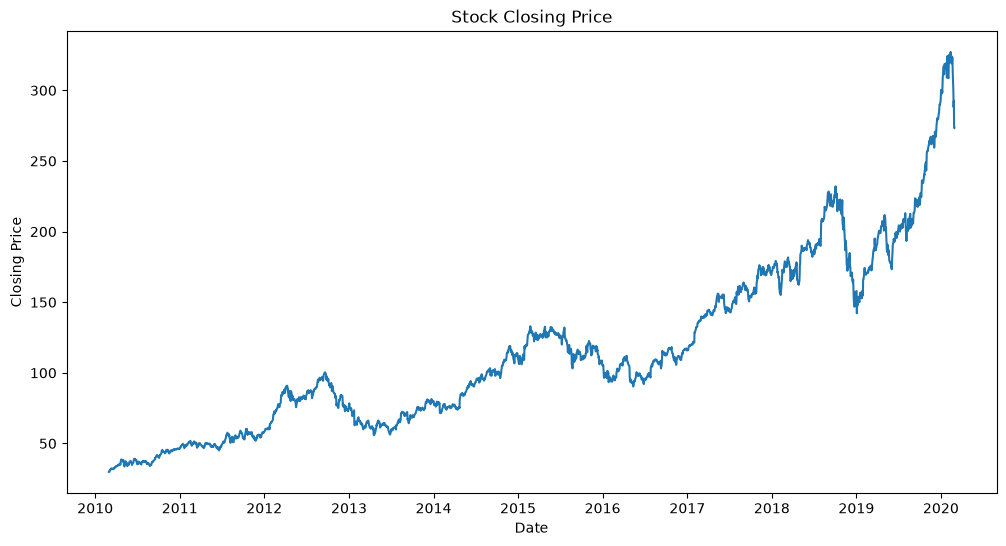

In [21]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

# Machine Learning Model Building

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
model = LinearRegression()

In [26]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.33, 0.34, 0.33,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Open','High','Low','Volume']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.002774
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


# Stock Price Prediction

In [27]:
y_pred = model.predict(X_test)

In [28]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
2196,191.4100,189.241638
410,57.4557,57.899827
1389,110.3700,111.843894
888,72.3100,72.222066
1772,138.9900,139.376564
56,35.4771,35.464389
44,38.0500,37.803666
1106,94.7200,94.613971
368,53.8557,53.870519
1738,119.9700,119.807284


# Model Evaluation

In [29]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 0.7449120511137433
Mean Squared Error: 1.2911219955245579
R2 Score: 0.9996035554803516


# Actual vs Predicted Price Visualization

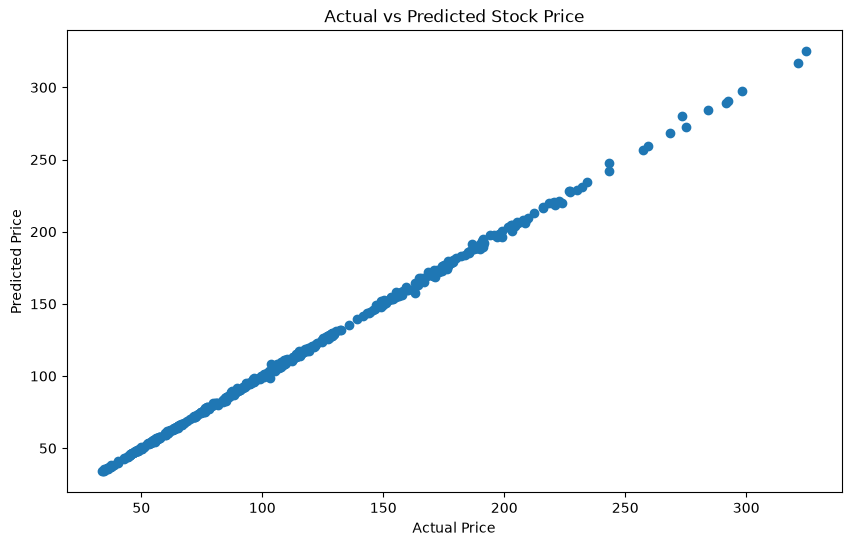

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Stock Price")
plt.show()

# Model Performance Summary

Mean Absolute Error (MAE): 0.7449
Mean Squared Error (MSE): 1.2911
R² Score: 0.9996

### Conclusion
The Linear Regression model achieved excellent performance in predicting stock closing prices. The very low error values and an R² score of 0.9996 indicate that the model accurately captures the relationship between the selected features (Open, High, Low, and Volume) and the closing price.